In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [3]:
spectra = []

for i in range(1, 25):
    df = pd.read_csv(f"Spectrum_{i}_gas_exp.csv")
    spectra.append(df)
    
SNR_HA = pd.read_csv("SNR_HA.csv")
SNR_HB = pd.read_csv("SNR_HB.csv") 
SNR_NII_2 = pd.read_csv("SNR_NII_2.csv") 
SNR_OIII_2 = pd.read_csv("SNR_OIII_2.csv") 
SNR_SII_1 = pd.read_csv("SNR_SII_1.csv") 

In [4]:
spectra[0]

,Name,Flux,Error_flux
0,Hgamma,0.215686,0.060059
1,Hbeta,0.312161,0.067312
2,Halpha,1.366029,0.052866
3,[SII]6716,0.189250,0.035438
4,[SII]6731,0.072373,0.019338
5,HeII4687,0.000000,0.021755
6,HeI5876,0.000000,0.017776
7,[OIII]4959,0.036528,0.040733
8,[OIII]5007,0.109584,0.040733
9,[OI]6300,0.046960,0.044219


In [5]:
def Ku03(x):
    # AGN selection based on Kauffman et al. 2003
    # log OIII/Hb > 0.61/(log NII/Ha - 0.05) + 1.3
    return 0.61/(x - 0.05) + 1.3

def Ke01(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.61/(log NII/Ha - 0.47) + 1.19
     return 0.61/(x - 0.47) + 1.19

def S06(x):
    # AGN selection based on Stasinska et al 2006
     # log OIII/Hb > 0.29/(log NII/Ha +0.20) + 0.96
    return 0.29/(x + 0.20) + 0.96

def C10(x):
 # Seyfert–LINER line based on Cid Fernandes et al 2010
    return 1.01*x + 0.48

def Ke01_SII(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.72/(log SII/Ha - 0.32) + 1.3
     return 0.72/(x - 0.32) + 1.3

def Ke06(x):
    #Seyfert–LINER line
    return 1.89* x + 0.76

def error_ratio(err_1, err_2, flux_1, flux_2):
    try:
        e_1 = err_1 / (flux_1 * np.log(10)) if flux_1 != 0 else np.nan
        e_2 = err_2 / (flux_2 * np.log(10)) if flux_2 != 0 else np.nan
        return np.sqrt(e_1**2 + e_2**2)
    except:
        return np.nan

def ratio(spectrum_1):
    flux = spectrum_1['Flux']
    err_flux = spectrum_1['Error_flux']

    OIII = flux[7]
    HB   = flux[0]
    NII  = flux[11]
    HA   = flux[1]
    SII  = flux[2]

    OIII_HB = np.log10(OIII / HB) if OIII > 0 and HB > 0 else np.nan
    NII_HA  = np.log10(NII / HA)  if NII > 0 and HA > 0 else np.nan
    SII_HA  = np.log10(SII / HA)  if SII > 0 and HA > 0 else np.nan

    err_OIII_HB = error_ratio(err_flux[7], err_flux[0], OIII, HB)
    err_NII_HA  = error_ratio(err_flux[11], err_flux[1], NII, HA)
    err_SII_HA  = error_ratio(err_flux[2], err_flux[1], SII, HA)

    return OIII_HB, NII_HA, SII_HA, err_OIII_HB, err_NII_HA, err_SII_HA

def evaluation_SNR(SNR_HA, SNR_HB, SNR_NII, SNR_SII, SNR_OIII):
    if (SNR_HB < 0) and (SNR_OIII >= 3) and (SNR_HA >= 3) and (SNR_NII >= 3) and (SNR_SII >= 3):
        return True 
    elif (SNR_HB >= 3) and (SNR_OIII >= 3) and (SNR_HA >= 3) and (SNR_NII >= 3) and (SNR_SII >= 3):
        return True 
    elif (SNR_HB >= 0) and (SNR_OIII >= 3) and (SNR_HA >= 3) and (SNR_NII >= 3) and (SNR_SII >= 3):
        print('Mettere freccia verso alto')
        return True
    else: return False 

Nan: 1
36.928 0.871 11.758 7.573 -0.507
Nan: 2
1.361 -1.72 1.707 -0.43 1.821
Nan: 3
-0.908 -2.203 1.369 -1.225 2.382
Nan: 4
-2.5 2.042 0.674 -0.031 -3.106
Nan: 5
-4.417 -3.965 15.642 1.421 0.142
Nan: 6
-1.193 -3.351 11.559 1.579 1.421
Nan: 7
-2.119 -1.823 1.182 1.523 0.274
Nan: 8
-1.49 -4.654 1.33 -2.793 1.85
Nan: 9
1.66 -1.324 1.856 0.386 0.435
Nan: 10
105.183 6.49 28.889 5.345 2.859
Nan: 11
17.07 3.19 5.173 2.126 -0.681
Nan: 12
5.304 0.329 2.632 -1.666 1.532
Nan: 13
2.327 -0.368 1.064 3.939 -0.172
Nan: 14
2.798 0.365 1.597 -0.831 1.137
Nan: 15
8.086 -0.161 4.228 0.634 1.068
Nan: 16
2.667 -0.29 1.578 0.596 0.182
Nan: 17
55.314 2.534 26.884 9.901 2.52
Nan: 18
43.886 3.656 23.138 11.054 0.059
Nan: 19
55.965 7.721 38.047 21.129 1.695
Nan: 20
14.293 3.356 8.127 5.905 -1.365
Nan: 21
33.158 4.506 13.371 10.677 0.445
Nan: 22
37.926 3.346 13.757 3.064 2.33
Nan: 23
3.885 0.208 2.666 0.334 0.133
Nan: 24
0.279 -0.652 0.742 0.974 -0.864


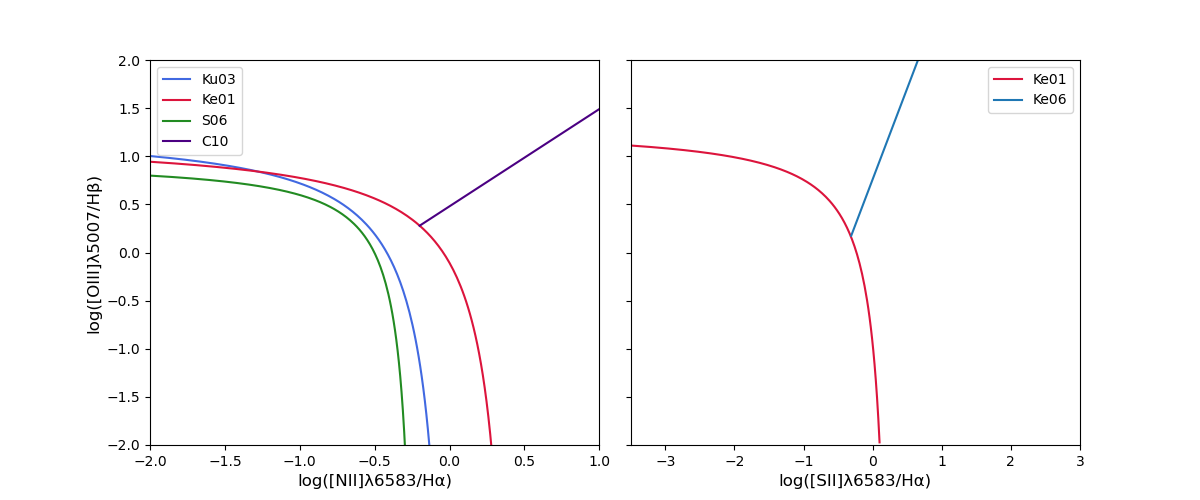

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.2, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
ax[0].plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
ax[0].plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
ax[0].plot(x3, C10(x3), label = 'C10', color = 'indigo')

x = np.linspace(-3.5, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01', color = 'crimson')
ax[1].plot(x1, Ke06(x1), label = 'Ke06')

NII_HA =[]
OIII_HB =[]
SII_HA =[]
for i in range(len(spectra)):
    SNR = evaluation_SNR(SNR_HA['SNR'][i], SNR_HB['SNR'][i], SNR_NII_2['SNR'][i], SNR_SII_1['SNR'][i], SNR_OIII_2['SNR'][i])
    if SNR == True: 
        spectrum = spectra[i]
        oiii_hb, nii_ha, sii_ha, err_oiii_hb, err_nii_ha, err_sii_ha = ratio(spectrum)
        if np.isnan(oiii_hb) == False:
            OIII_HB.append(oiii_hb)
        if np.isnan(sii_ha) == False:
            SII_HA.append(sii_ha)
        if np.isnan(nii_ha) == False:    
            NII_HA.append(nii_ha)
        print('Numero ok:', i+1)
    
    else: 
        oiii_hb = np.nan
        nii_ha = np.nan
        sii_ha = np.nan
        err_oiii_hb = np.nan
        err_nii_ha = np.nan
        err_sii_ha = np.nan
        NII_HA.append(nii_ha)
        OIII_HB.append(oiii_hb)
        SII_HA.append(sii_ha)
        print('Nan:', i+1)
        print(SNR_HA['SNR'][i], SNR_HB['SNR'][i], SNR_NII_2['SNR'][i], SNR_SII_1['SNR'][i], SNR_OIII_2['SNR'][i])
        
OIII_HB_ok = []
SII_HA_ok = []
NII_HA_ok = []

for i in range(len(spectra)):
    if np.isnan(OIII_HB[i]) == False:
        OIII_HB_ok.append(OIII_HB[i])
    if np.isnan(SII_HA[i]) == False:
        SII_HA_ok.append(SII_HA[i])
    if np.isnan(NII_HA[i]) == False:
        NII_HA_ok.append(NII_HA[i])
    
ax[0].plot(NII_HA, OIII_HB, color='blue', marker= 's', linestyle='-', markersize = 3)   
ax[0].plot(NII_HA[0], OIII_HB[0], color='red', marker= 's', linestyle='-', markersize = 3) 
ax[0].plot(NII_HA[-1], OIII_HB[-1], color='orange', marker= 's', linestyle='-', markersize = 3) 
ax[1].plot(SII_HA, OIII_HB, color='blue', marker= 's', linestyle='-', markersize = 3)
ax[1].plot(SII_HA[0], OIII_HB[0], color='green', marker= 's', linestyle='-', markersize = 3)
ax[1].plot(SII_HA[-1], OIII_HB[-1], color='purple', marker= 's', linestyle='-', markersize = 3)

ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

ax[1].set_xlim(-3.5, 3)
ax[1].set_ylim(-2, 2)
ax[1].set_xlabel('log([SII]λ6583/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.07)

IndexError: list index out of range

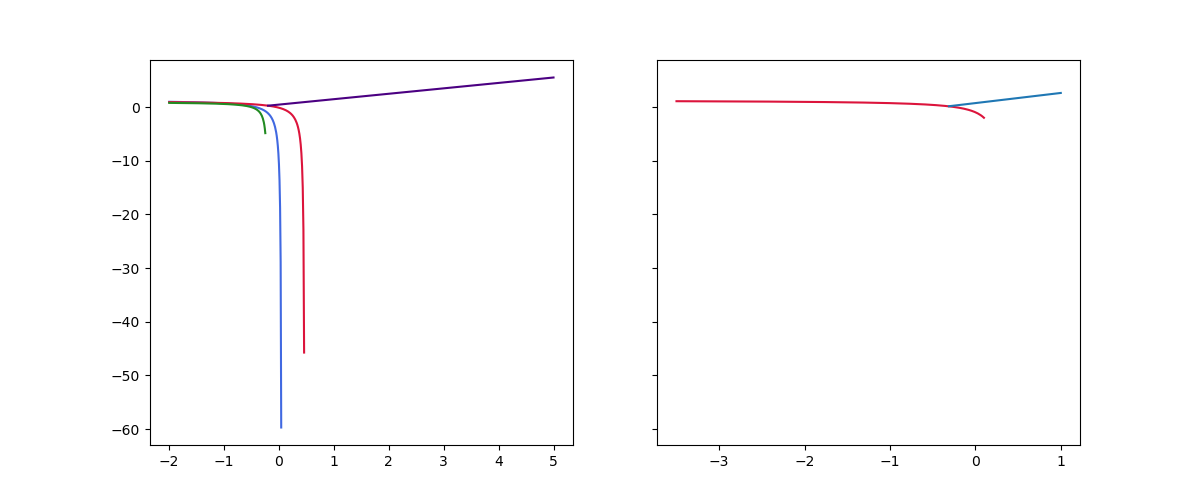

In [7]:
fig2, ax2 = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.2, 5, num=200)
ax2[0].plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
ax2[0].plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
ax2[0].plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
ax2[0].plot(x3, C10(x3), label = 'C10', color = 'indigo')

x = np.linspace(-3.5, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax2[1].plot(x, Ke01_SII(x), label = 'Ke01', color = 'crimson')
ax2[1].plot(x1, Ke06(x1), label = 'Ke06')

ax2[0].plot(NII_HA_ok, OIII_HB_ok, color='blue', marker= 's', linestyle='-', markersize = 3)   
ax2[0].plot(NII_HA_ok[0], OIII_HB_ok[0], color='red', marker= 's', linestyle='-', markersize = 3, label ='First') 
ax2[0].plot(NII_HA_ok[3], OIII_HB_ok[3], color='blue', marker= '^', linestyle='-', markersize = 5)
ax2[0].plot(NII_HA_ok[-2], OIII_HB_ok[-2], color='blue', marker= '^', linestyle='-', markersize = 5)   
ax2[0].plot(NII_HA_ok[-1], OIII_HB_ok[-1], color='orange', marker= 's', linestyle='-', markersize = 3, label ='Last') 
ax2[1].plot(SII_HA_ok, OIII_HB_ok, color='blue', marker= 's', linestyle='-', markersize = 3)
ax2[1].plot(SII_HA_ok[0], OIII_HB_ok[0], color='green', marker= 's', linestyle='-', markersize = 3,label ='First')
ax2[1].plot(SII_HA_ok[-1], OIII_HB_ok[-1], color='purple', marker= 's', linestyle='-', markersize = 3, label ='Last')

ax2[0].set_xlim(-2, 1)
ax2[0].set_ylim(-1.5, 2)
ax2[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax2[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax2[0].legend()

ax2[1].set_xlim(-3.5, 3)
ax2[1].set_ylim(-2, 2)
ax2[1].set_xlabel('log([SII]λ6583/Hα)', fontsize=12)
ax2[1].legend()

plt.subplots_adjust(wspace=0.07)
plt.savefig('BPT_grad.png', bbox_inches='tight')